Dataset shape: (20000, 13)
  session_id  baby_age_months audio_predicted_class  audio_confidence  \
0     S00001               10                Hunger              0.91   
1     S00002                3                Hunger              0.64   
2     S00003               12                Hunger              0.59   
3     S00004               12                Hunger              0.88   
4     S00005               11                Hunger              0.59   

  image_predicted_class  image_confidence  time_since_feed_hours  \
0               No-Pain              0.72                    4.5   
1               No-Pain              0.87                    4.2   
2               No-Pain              0.89                    3.8   
3               No-Pain              0.89                    3.9   
4               No-Pain              0.80                    4.3   

   time_since_sleep_hours diaper_status  room_temperature_celsius  \
0                     1.2         Clean                 

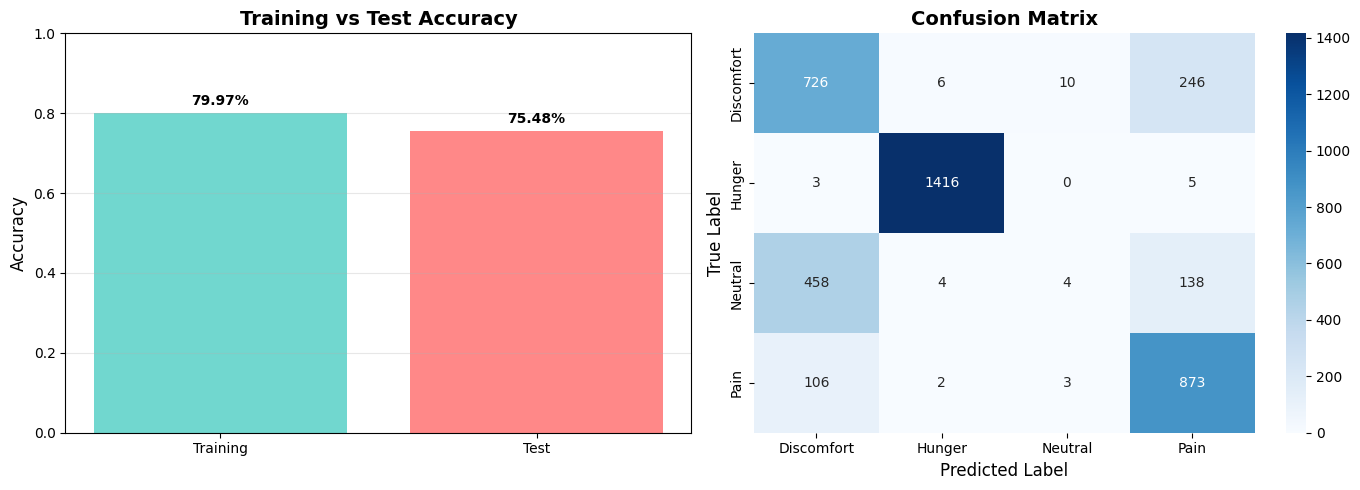


📈 PER-CLASS ACCURACY
Discomfort          : 0.7348 (73.48%)
Hunger              : 0.9944 (99.44%)
Neutral             : 0.0066 (0.66%)
Pain                : 0.8872 (88.72%)

🔍 INFERENCE RESULT
Predicted Cry Reason: Hunger
Confidence: 100.00%

All Class Probabilities:
  Discomfort     : 0.00%
  Hunger         : 100.00%
  Neutral        : 0.00%
  Pain           : 0.00%


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

# ==============================
# 1. LOAD DATASET
# ==============================
DATA_PATH = r"F:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\data\raw\Fusion\synthetic_pediatric_cry_fusion_dataset_20k.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())

# ==============================
# 2. DEFINE FEATURES & TARGET
# ==============================
TARGET = "true_cry_reason"

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Encode target labels to numeric (XGBoost requirement)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\n" + "="*50)
print("TARGET LABEL ENCODING")
print("="*50)
for i, label in enumerate(label_encoder.classes_):
    print(f"{i} -> {label}")
print("="*50)

# ==============================
# 3. FEATURE GROUPS
# ==============================
categorical_features = [
    "audio_predicted_class",
    "image_predicted_class",
    "diaper_status"
]

numeric_features = [
    "audio_confidence",
    "image_confidence",
    "time_since_feed_hours",
    "time_since_sleep_hours",
    "room_temperature_celsius",
    "baby_age_months"
]

# ==============================
# 4. PREPROCESSOR
# ==============================
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# ==============================
# 5. BASE FUSION MODEL
# ==============================
base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

# ==============================
# 6. PIPELINE
# ==============================
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", base_model)
])

# ==============================
# 7. TRAIN / TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,  # Use encoded labels
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# ==============================
# 8. CALIBRATED MODEL (IMPORTANT)
# ==============================
calibrated_model = CalibratedClassifierCV(
    estimator=pipeline,
    method="isotonic",
    cv=5
)

print("\nTraining model...")
calibrated_model.fit(X_train, y_train)
print("✅ Model trained successfully!")

# ==============================
# 9. EVALUATION
# ==============================
y_pred = calibrated_model.predict(X_test)
y_prob = calibrated_model.predict_proba(X_test)

# Calculate accuracies
train_accuracy = calibrated_model.score(X_train, y_train)
test_accuracy = calibrated_model.score(X_test, y_test)

print("\n" + "="*50)
print("📊 MODEL ACCURACY METRICS")
print("="*50)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Overfitting Gap:   {(train_accuracy - test_accuracy):.4f}")
print("="*50)

# Convert predictions back to original labels for reporting
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ==============================
# 10. VISUALIZE ACCURACY
# ==============================
# Plot accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar plot
axes[0].bar(['Training', 'Test'], [train_accuracy, test_accuracy], 
            color=['#4ECDC4', '#FF6B6B'], alpha=0.8)
axes[0].set_ylim([0, 1])
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training vs Test Accuracy', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate([train_accuracy, test_accuracy]):
    axes[0].text(i, v + 0.02, f'{v*100:.2f}%', ha='center', fontweight='bold')

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================
# 11. PER-CLASS ACCURACY
# ==============================
print("\n" + "="*50)
print("📈 PER-CLASS ACCURACY")
print("="*50)
for cls_name in label_encoder.classes_:
    mask = y_test_labels == cls_name
    if mask.sum() > 0:
        cls_accuracy = (y_pred_labels[mask] == cls_name).mean()
        print(f"{cls_name:20s}: {cls_accuracy:.4f} ({cls_accuracy*100:.2f}%)")
print("="*50)

# ==============================
# 12. INFERENCE FUNCTION
# ==============================
def predict_cry_reason(sample_dict):
    """
    sample_dict: dictionary with same keys as dataset features
    """
    sample_df = pd.DataFrame([sample_dict])
    
    # Get encoded predictions
    pred_encoded = calibrated_model.predict(sample_df)[0]
    probs = calibrated_model.predict_proba(sample_df)[0]
    
    # Convert back to original labels
    predicted_label = label_encoder.inverse_transform([pred_encoded])[0]
    
    # Create probability dict with original labels
    prob_dict = {
        label: float(probs[i]) 
        for i, label in enumerate(label_encoder.classes_)
    }

    return {
        "predicted_cry_reason": predicted_label,
        "confidence": float(probs[pred_encoded]),
        "all_class_probabilities": prob_dict
    }

# ==============================
# 13. EXAMPLE REAL-WORLD INFERENCE
# ==============================
example_input = {
    "session_id": "NEW_001",
    "baby_age_months": 6,
    "audio_predicted_class": "Hunger",
    "audio_confidence": 0.82,
    "image_predicted_class": "No-Pain",
    "image_confidence": 0.76,
    "time_since_feed_hours": 4.5,
    "time_since_sleep_hours": 1.2,
    "diaper_status": "Clean",
    "room_temperature_celsius": 26,
    "model_disagreement": True,
    "ambiguous_case": False
}

result = predict_cry_reason(example_input)

print("\n" + "="*50)
print("🔍 INFERENCE RESULT")
print("="*50)
print(f"Predicted Cry Reason: {result['predicted_cry_reason']}")
print(f"Confidence: {result['confidence']*100:.2f}%")
print("\nAll Class Probabilities:")
for cls, prob in result['all_class_probabilities'].items():
    print(f"  {cls:15s}: {prob*100:.2f}%")
print("="*50)

In [3]:
# ==============================
# 14. SAVE MODEL FOR PRODUCTION
# ==============================
import joblib
import os

# Create directory for saved models if it doesn't exist
save_dir = r"F:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\saved_models"
os.makedirs(save_dir, exist_ok=True)

# Save the calibrated model
model_path = os.path.join(save_dir, "fusion_model_calibrated.pkl")
joblib.dump(calibrated_model, model_path)
print(f"✅ Model saved to: {model_path}")

# Save the label encoder
encoder_path = os.path.join(save_dir, "fusion_label_encoder.pkl")
joblib.dump(label_encoder, encoder_path)
print(f"✅ Label encoder saved to: {encoder_path}")

print("\n" + "="*50)
print("🎉 MODEL DEPLOYMENT FILES READY")
print("="*50)
print(f"Model: {model_path}")
print(f"Encoder: {encoder_path}")
print("="*50)

✅ Model saved to: F:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\saved_models\fusion_model_calibrated.pkl
✅ Label encoder saved to: F:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\saved_models\fusion_label_encoder.pkl

🎉 MODEL DEPLOYMENT FILES READY
Model: F:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\saved_models\fusion_model_calibrated.pkl
Encoder: F:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\saved_models\fusion_label_encoder.pkl
